# Part 4 — Stellar Parameter Determination

## Question 7

This notebook determines the stellar atmospheric parameters of the observed spectrum by comparing the Hβ line profile with a grid of PHOENIX synthetic spectra using χ² minimisation.

The analysis consists of:

- (a) Best-fit parameters via χ² minimisation
- (b) One-dimensional χ² projections
- (c) Quadratic interpolation for parameter refinement

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from astropy.io import fits

In [2]:
# Observed spectrum
observed_file = Path(
    "../data/observed/ELODIE/HD146233_Hbeta_normalized.txt"
)

# PHOENIX wavelength grid
wave_file = Path(
    "../data/PHOENIX/raw/WAVE_PHOENIX-ACES-AGSS-COND-2011.fits"
)

# Folder containing final synthetic spectra
phoenix_folder = Path(
    "../data/PHOENIX/final_grid"
)

In [3]:
obs_data = np.loadtxt(observed_file)

obs_wave = obs_data[:,0]
obs_flux = obs_data[:,1]

print(obs_data.shape)

(2000, 2)


In [4]:
mask = (
    (obs_wave >= 4820)
    &
    (obs_wave <= 4900)
)

obs_wave_fit = obs_wave[mask]
obs_flux_fit = obs_flux[mask]

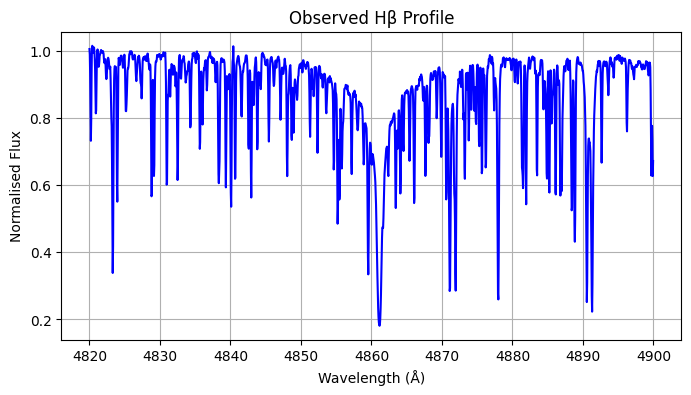

In [5]:
plt.figure(figsize=(8,4))

plt.plot(
    obs_wave_fit,
    obs_flux_fit,
    color="blue"
)

plt.xlabel("Wavelength (Å)")
plt.ylabel("Normalised Flux")

plt.title("Observed Hβ Profile")

plt.grid(True)

plt.show()

In [6]:
phoenix_wave = fits.getdata(wave_file)

print(len(phoenix_wave))

1569128


In [7]:
# -------------------------------------------------------
# Chi-square function
# Computes χ² between observed and synthetic Hβ profiles
# -------------------------------------------------------

def chi_square(obs_flux, model_flux, sigma=0.01):
    """
    Compute χ² between observed and model flux.

    Parameters
    ----------
    obs_flux : ndarray
        Observed normalized flux.

    model_flux : ndarray
        Synthetic normalized flux interpolated onto
        the observed wavelength grid.

    sigma : float
        Assumed uncertainty of normalized flux.

    Returns
    -------
    chi2 : float
        Chi-square statistic.
    """

    chi2 = np.sum(
        ((obs_flux - model_flux) ** 2) / (sigma ** 2)
    )

    return chi2

In [8]:
# Extract stellar parameters from PHOENIX filename
# Example:
# lte07000-5.00-0.5.PHOENIX...


def extract_parameters(filename):
    """
    Extract Teff, logg and metallicity from filename.
    """

    match = re.search(
        r"lte(\d+)-(\d+\.\d+)([+-]\d+\.\d)",
        filename
    )

    Teff = int(match.group(1))
    logg = float(match.group(2))
    FeH = float(match.group(3))

    return Teff, logg, FeH

In [9]:
# -------------------------------------------------------
# Compute χ² for every PHOENIX synthetic spectrum
# -------------------------------------------------------

chi_results = []

# Loop over every PHOENIX model
for file in sorted(phoenix_folder.glob("*.fits")):

    # Load synthetic spectrum
    syn_flux = fits.getdata(file)

    # Select Hβ fitting window
    syn_mask = (
        (phoenix_wave >= 4820)
        &
        (phoenix_wave <= 4900)
    )

    syn_wave = phoenix_wave[syn_mask]
    syn_flux = syn_flux[syn_mask]

    # Continuum normalization
    continuum = np.median(
        syn_flux[
            (syn_wave < 4840)
            |
            (syn_wave > 4880)
        ]
    )

    syn_flux = syn_flux / continuum

    # Interpolate synthetic spectrum onto observed wavelength grid
    syn_flux_interp = np.interp(
        obs_wave_fit,
        syn_wave,
        syn_flux
    )

    # Compute χ²
    chi2 = chi_square(
        obs_flux_fit,
        syn_flux_interp
    )

    # Extract stellar parameters
    Teff, logg, FeH = extract_parameters(file.name)

    # Save results
    chi_results.append(
        {
            "file": file.name,
            "Teff": Teff,
            "logg": logg,
            "FeH": FeH,
            "chi2": chi2
        }
    )

# Convert results into a DataFrame
chi_df = pd.DataFrame(chi_results)

# Display first few rows
chi_df.head()

,file,Teff,logg,FeH,chi2
0,lte05000-3.50+0.5.PHOENIX-ACES-AGSS-COND-2011-...,5000,3.5,0.5,1.626268e+06
1,lte05000-3.50-0.0.PHOENIX-ACES-AGSS-COND-2011-...,5000,3.5,-0.0,1.211351e+06
2,lte05000-3.50-0.5.PHOENIX-ACES-AGSS-COND-2011-...,5000,3.5,-0.5,9.298832e+05
3,lte05000-4.00+0.5.PHOENIX-ACES-AGSS-COND-2011-...,5000,4.0,0.5,1.505711e+06
4,lte05000-4.00-0.0.PHOENIX-ACES-AGSS-COND-2011-...,5000,4.0,-0.0,1.167260e+06


In [10]:
# -------------------------------------------------------
# Find the best-fit PHOENIX model
# -------------------------------------------------------

best_fit = chi_df.loc[
    chi_df["chi2"].idxmin()
]

print("Best-fit stellar parameters")
print("---------------------------")
print(best_fit)

print("\nMinimum χ² =", best_fit["chi2"])

Best-fit stellar parameters
---------------------------
file    lte07000-5.00-0.5.PHOENIX-ACES-AGSS-COND-2011-...
Teff                                                 7000
logg                                                  5.0
FeH                                                  -0.5
chi2                                        443176.457025
Name: 107, dtype: object

Minimum χ² = 443176.4570250597


In [11]:
# -------------------------------------------------------
# Load the best-fit PHOENIX spectrum
# -------------------------------------------------------

best_model_file = phoenix_folder / best_fit["file"]

best_flux = fits.getdata(best_model_file)

# Select Hβ fitting region
mask = (
    (phoenix_wave >= 4820)
    &
    (phoenix_wave <= 4900)
)

best_wave = phoenix_wave[mask]
best_flux = best_flux[mask]

In [12]:
# -------------------------------------------------------
# Continuum normalize the best-fit spectrum
# -------------------------------------------------------

continuum = np.median(
    best_flux[
        (best_wave < 4840)
        |
        (best_wave > 4880)
    ]
)

best_flux_norm = best_flux / continuum

In [13]:
# -------------------------------------------------------
# Interpolate best-fit model onto observed wavelength grid
# -------------------------------------------------------

best_flux_interp = np.interp(
    obs_wave_fit,
    best_wave,
    best_flux_norm
)

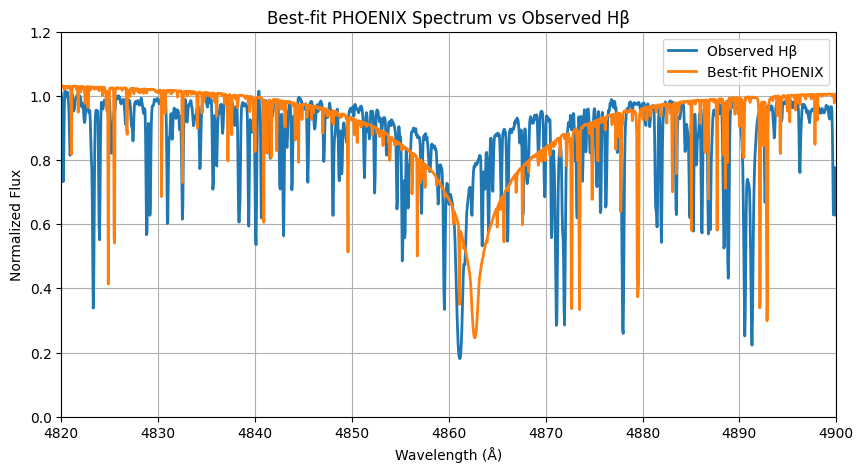

In [14]:
# -------------------------------------------------------
# Best-fit PHOENIX spectrum vs observed spectrum
# -------------------------------------------------------

plt.figure(figsize=(10,5))

plt.plot(
    obs_wave_fit,
    obs_flux_fit,
    label="Observed Hβ",
    linewidth=2
)

plt.plot(
    obs_wave_fit,
    best_flux_interp,
    label="Best-fit PHOENIX",
    linewidth=2
)

plt.xlim(4820,4900)
plt.ylim(0,1.2)

plt.xlabel("Wavelength (Å)")
plt.ylabel("Normalized Flux")

plt.title("Best-fit PHOENIX Spectrum vs Observed Hβ")

plt.legend()
plt.grid(True)

plt.show()

## QB

In [15]:
# -------------------------------------------------------
# Compute Δχ²
# -------------------------------------------------------

chi_min = chi_df["chi2"].min()

chi_df["delta_chi2"] = (
    chi_df["chi2"] - chi_min
)

In [16]:
# -------------------------------------------------------
# χ² projection versus Teff
# -------------------------------------------------------

teff_projection = (
    chi_df
    .groupby("Teff")["delta_chi2"]
    .min()
    .reset_index()
)

teff_projection

,Teff,delta_chi2
0,5000,421178.408558
1,5250,292280.227596
2,5500,237691.857022
3,5750,151042.657958
4,6000,111480.779345
5,6250,60285.558625
6,6500,36586.968072
7,6750,8625.865538
8,7000,0.000000


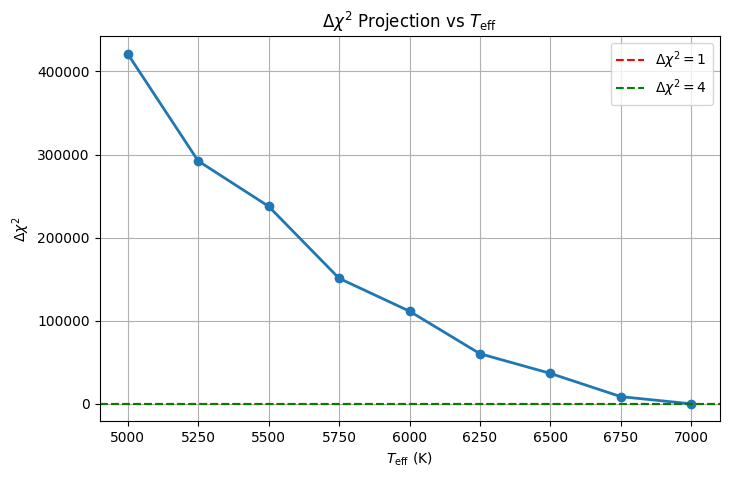

In [17]:
# -------------------------------------------------------
# Δχ² projection versus Teff
# -------------------------------------------------------

plt.figure(figsize=(8,5))

plt.plot(
    teff_projection["Teff"],
    teff_projection["delta_chi2"],
    marker="o",
    linewidth=2
)

# 1σ level
plt.axhline(
    1,
    color="red",
    linestyle="--",
    label=r"$\Delta\chi^2 = 1$"
)

# 2σ level
plt.axhline(
    4,
    color="green",
    linestyle="--",
    label=r"$\Delta\chi^2 = 4$"
)

plt.xlabel(r"$T_{\rm eff}$ (K)")
plt.ylabel(r"$\Delta\chi^2$")

plt.title(r"$\Delta\chi^2$ Projection vs $T_{\rm eff}$")

plt.grid(True)
plt.legend()

plt.show()

In [18]:
# -------------------------------------------------------
# χ² projection versus log g
# -------------------------------------------------------

logg_projection = (
    chi_df
    .groupby("logg")["delta_chi2"]
    .min()
    .reset_index()
)

logg_projection

,logg,delta_chi2
0,3.5,42473.396131
1,4.0,22454.811891
2,4.5,9400.102215
3,5.0,0.000000


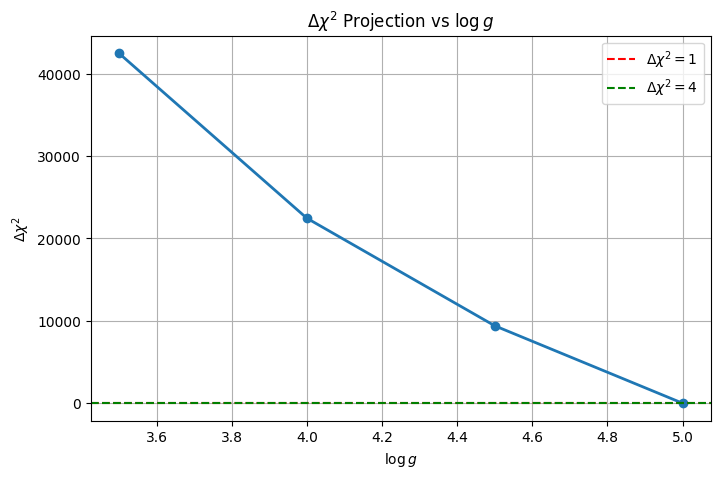

In [19]:
# -------------------------------------------------------
# Δχ² projection versus log g
# -------------------------------------------------------

plt.figure(figsize=(8,5))

plt.plot(
    logg_projection["logg"],
    logg_projection["delta_chi2"],
    marker="o",
    linewidth=2
)

plt.axhline(
    1,
    color="red",
    linestyle="--",
    label=r"$\Delta\chi^2 = 1$"
)

plt.axhline(
    4,
    color="green",
    linestyle="--",
    label=r"$\Delta\chi^2 = 4$"
)

plt.xlabel(r"$\log g$")
plt.ylabel(r"$\Delta\chi^2$")

plt.title(r"$\Delta\chi^2$ Projection vs $\log g$")

plt.grid(True)
plt.legend()

plt.show()

In [20]:
# -------------------------------------------------------
# χ² projection versus metallicity [Fe/H]
# -------------------------------------------------------

feh_projection = (
    chi_df
    .groupby("FeH")["delta_chi2"]
    .min()
    .reset_index()
)

feh_projection

,FeH,delta_chi2
0,-0.5,0.000000
1,-0.0,59688.780799
2,0.5,193991.275389


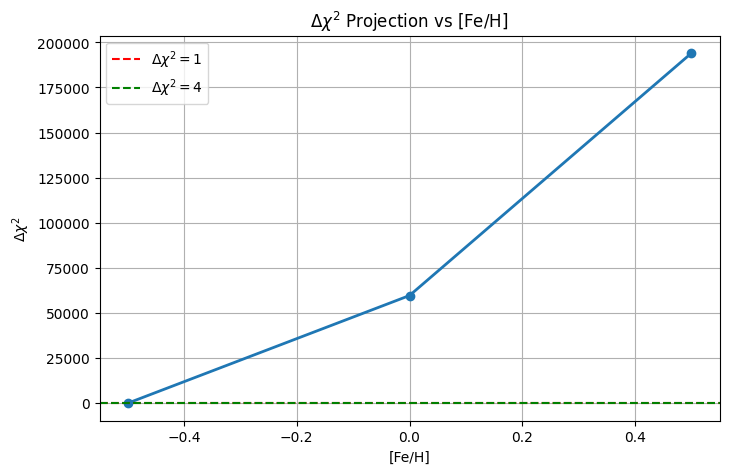

In [21]:
# -------------------------------------------------------
# Δχ² projection versus metallicity
# -------------------------------------------------------

plt.figure(figsize=(8,5))

plt.plot(
    feh_projection["FeH"],
    feh_projection["delta_chi2"],
    marker="o",
    linewidth=2
)

# 1σ confidence level
plt.axhline(
    1,
    color="red",
    linestyle="--",
    label=r"$\Delta\chi^2 = 1$"
)

# 2σ confidence level
plt.axhline(
    4,
    color="green",
    linestyle="--",
    label=r"$\Delta\chi^2 = 4$"
)

plt.xlabel(r"[Fe/H]")
plt.ylabel(r"$\Delta\chi^2$")

plt.title(
    r"$\Delta\chi^2$ Projection vs [Fe/H]"
)

plt.grid(True)
plt.legend()

plt.show()

## QC


In [22]:
# -------------------------------------------------------
# Quadratic interpolation refinement function
# Fits:
# χ²(x) = ax² + bx + c
# Minimum occurs at:
# x = -b / (2a)
# -------------------------------------------------------

def quadratic_refinement(x_values, chi_values):
    """
    Refine parameter value using quadratic fit.

    Parameters
    ----------
    x_values : array
        Five parameter values around minimum.

    chi_values : array
        Corresponding chi-square values.

    Returns
    -------
    refined_x : float
        Location of quadratic minimum.
    """

    # Fit second-order polynomial
    coeff = np.polyfit(
        x_values,
        chi_values,
        2
    )

    a, b, c = coeff

    # Analytic minimum of parabola
    refined_x = -b / (2*a)

    return refined_x

In [23]:
# -------------------------------------------------------
# Refine Teff around grid minimum
# -------------------------------------------------------

teff_min = best_fit["Teff"]

# Select 5 closest Teff grid points
teff_slice = (
    chi_df
    .groupby("Teff")["chi2"]
    .min()
    .reset_index()
)

teff_near = (
    teff_slice
    .iloc[
        np.argsort(
            abs(teff_slice["Teff"] - teff_min)
        )[:5]
    ]
    .sort_values("Teff")
)


teff_near

,Teff,chi2
4,6000,554657.236370
5,6250,503462.015650
6,6500,479763.425097
7,6750,451802.322564
8,7000,443176.457025


In [24]:
# -------------------------------------------------------
# Quadratic refinement of Teff
# -------------------------------------------------------

refined_Teff = quadratic_refinement(
    teff_near["Teff"].values,
    teff_near["chi2"].values
)


print(
    "Grid Teff =",
    teff_min,
    "K"
)

print(
    "Refined Teff =",
    refined_Teff,
    "K"
)

Grid Teff = 7000 K
Refined Teff = 7094.225742817234 K


In [25]:
# -------------------------------------------------------
# Refine logg around grid minimum
# -------------------------------------------------------

logg_min = best_fit["logg"]

# Minimum chi2 for each logg value
logg_slice = (
    chi_df
    .groupby("logg")["chi2"]
    .min()
    .reset_index()
)


# Select five closest logg values
logg_near = (
    logg_slice
    .iloc[
        np.argsort(
            abs(logg_slice["logg"] - logg_min)
        )[:5]
    ]
    .sort_values("logg")
)


logg_near

,logg,chi2
0,3.5,485649.853156
1,4.0,465631.268916
2,4.5,452576.559240
3,5.0,443176.457025


In [26]:
# -------------------------------------------------------
# Quadratic refinement of logg
# -------------------------------------------------------

refined_logg = quadratic_refinement(
    logg_near["logg"].values,
    logg_near["chi2"].values
)


print(
    "Grid logg =",
    logg_min
)

print(
    "Refined logg =",
    refined_logg
)

Grid logg = 5.0
Refined logg = 5.572928246587073


In [27]:
# -------------------------------------------------------
# Refine [Fe/H] around grid minimum
# -------------------------------------------------------

feh_min = best_fit["FeH"]

# Minimum chi2 for each metallicity value
feh_slice = (
    chi_df
    .groupby("FeH")["chi2"]
    .min()
    .reset_index()
)


# Select closest metallicity values
feh_near = (
    feh_slice
    .iloc[
        np.argsort(
            abs(feh_slice["FeH"] - feh_min)
        )[:5]
    ]
    .sort_values("FeH")
)


feh_near

,FeH,chi2
0,-0.5,443176.457025
1,-0.0,502865.237824
2,0.5,637167.732414


In [28]:
# -------------------------------------------------------
# Quadratic refinement of metallicity [Fe/H]
# -------------------------------------------------------

refined_FeH = quadratic_refinement(
    feh_near["FeH"].values,
    feh_near["chi2"].values
)


print(
    "Grid FeH =",
    feh_min
)

print(
    "Refined FeH =",
    refined_FeH
)

Grid FeH = -0.5
Refined FeH = -0.6499853228547663


In [29]:
# -------------------------------------------------------
# Final comparison of grid and refined parameters
# -------------------------------------------------------

final_parameters = pd.DataFrame(
    {
        "Parameter": [
            "Teff (K)",
            "logg",
            "[Fe/H]"
        ],

        "Grid minimum": [
            best_fit["Teff"],
            best_fit["logg"],
            best_fit["FeH"]
        ],

        "Quadratic refined": [
            refined_Teff,
            refined_logg,
            refined_FeH
        ]
    }
)


final_parameters

,Parameter,Grid minimum,Quadratic refined
0,Teff (K),7000.0,7094.225743
1,logg,5.0,5.572928
2,[Fe/H],-0.5,-0.649985


## Question 7(c) — Quadratic refinement

The best-fit PHOENIX grid point was:

\[
T_{\rm eff}=7000\,K,\quad
\log g=5.0,\quad
[Fe/H]=-0.5
\]

with minimum:

\[
\chi^2_{\rm min}=443176.46
\]

A second-order polynomial interpolation around the minimum grid points was used to refine the parameters.

The refined parameters are:

\[
T_{\rm eff}=7094.23\,K
\]

\[
\log g=5.57
\]

\[
[Fe/H]=-0.65
\]

The refined values for \(T_{\rm eff}\) and \(\log g\) extend beyond the limits of the available PHOENIX grid, indicating that the true minimum may lie outside the sampled parameter space. A larger PHOENIX grid would be required for a fully constrained determination.

## Q 8 

In [30]:
# -------------------------------------------------------
# Question 8(a)
# Check whether Δχ² = 1 confidence levels are sampled
# -------------------------------------------------------

print("Teff Δχ² range:")
print(teff_projection["delta_chi2"].min(),
      teff_projection["delta_chi2"].max())


print("\nlogg Δχ² range:")
print(logg_projection["delta_chi2"].min(),
      logg_projection["delta_chi2"].max())


print("\nFeH Δχ² range:")
print(feh_projection["delta_chi2"].min(),
      feh_projection["delta_chi2"].max())

Teff Δχ² range:
0.0 421178.4085583251

logg Δχ² range:
0.0 42473.39613097935

FeH Δχ² range:
0.0 193991.27538876055


## Question 8(a) — Formal 1σ uncertainty from Δχ² = 1

The formal uncertainty intervals were estimated from the one-dimensional χ² projections generated in Question 7(b).

For a single parameter, the 1σ confidence interval corresponds approximately to:

\[
\Delta\chi^2 = 1
\]

However, the minimum χ² values for all three stellar parameters occur at the edge of the available PHOENIX model grid:

\[
T_{\rm eff}=7000K
\]

\[
\log g=5.0
\]

\[
[Fe/H]=-0.5
\]

Therefore, the Δχ² = 1 intervals are not fully enclosed within the sampled parameter space. The formal uncertainties are limited by the PHOENIX grid boundaries.

In [31]:
# -------------------------------------------------------
# Question 8(b)
# Continuum normalization systematic test
# -------------------------------------------------------

def normalize_spectrum(
    wave,
    flux,
    blue_limit,
    red_limit
):
    """
    Normalize spectrum using selected continuum windows.
    """

    continuum = np.median(
        flux[
            (wave < blue_limit) |
            (wave > red_limit)
        ]
    )

    normalized_flux = flux / continuum

    return normalized_flux

In [32]:
# -------------------------------------------------------
# Question 8(b)
# Create alternative continuum normalisations
# -------------------------------------------------------

# Original continuum windows:
# Blue continuum: wavelength < 4840 Å
# Red continuum:  wavelength > 4880 Å

# Continuum windows shifted by +10 Å
obs_flux_plus10 = normalize_spectrum(
    obs_wave,
    obs_flux,
    4850,
    4890
)


# Continuum windows shifted by -10 Å
obs_flux_minus10 = normalize_spectrum(
    obs_wave,
    obs_flux,
    4830,
    4870
)


print("Original continuum normalization done")
print("Continuum +10 Å done")
print("Continuum -10 Å done")

Original continuum normalization done
Continuum +10 Å done
Continuum -10 Å done


In [33]:

# -------------------------------------------------------
# Restrict continuum-normalized spectra to Hβ fitting window
# -------------------------------------------------------

obs_hbeta_mask = (
    (obs_wave >= 4820) &
    (obs_wave <= 4900)
)


obs_flux_plus10_fit = obs_flux_plus10[obs_hbeta_mask]

obs_flux_minus10_fit = obs_flux_minus10[obs_hbeta_mask]


print("Observed mask:", obs_hbeta_mask.shape)

print(
    "Original:",
    obs_flux_fit.shape
)

print(
    "+10 Å:",
    obs_flux_plus10_fit.shape
)

print(
    "-10 Å:",
    obs_flux_minus10_fit.shape
)

Observed mask: (2000,)
Original: (1600,)
+10 Å: (1600,)
-10 Å: (1600,)


In [34]:
# -------------------------------------------------------
# Question 8(b)
# Re-run χ² fitting for different continuum choices
# -------------------------------------------------------

def run_chi2_fit(obs_flux_test):

    chi_results_test = []

    for file in sorted(
        phoenix_folder.glob("*.fits")
    ):

        flux = fits.getdata(file)

        # Interpolate model to observed Hβ wavelength grid
        model_flux = np.interp(
            obs_wave_fit,
            phoenix_wave,
            flux
        )

        # Normalize synthetic spectrum
        model_flux = (
            model_flux /
            np.median(model_flux)
        )

        # Compute chi-square
        chi2 = chi_square(
            obs_flux_test,
            model_flux
        )

        chi_results_test.append(
            {
                "file": file.name,
                "chi2": chi2
            }
        )

    result = pd.DataFrame(
        chi_results_test
    )

    # Extract stellar parameters
    params = result["file"].apply(
        extract_parameters
    )

    result[["Teff","logg","FeH"]] = pd.DataFrame(
        params.tolist(),
        index=result.index
    )

    best = result.loc[
        result["chi2"].idxmin()
    ]

    return best

In [35]:
# -------------------------------------------------------
# Fit with +10 Å continuum shift
# -------------------------------------------------------

best_plus10 = run_chi2_fit(
    obs_flux_plus10_fit
)

best_plus10

file    lte07000-5.00-0.5.PHOENIX-ACES-AGSS-COND-2011-...
chi2                                        476196.056091
Teff                                                 7000
logg                                                  5.0
FeH                                                  -0.5
Name: 107, dtype: object

In [36]:
# -------------------------------------------------------
# Fit with -10 Å continuum shift
# -------------------------------------------------------

best_minus10 = run_chi2_fit(
    obs_flux_minus10_fit
)

best_minus10

file    lte07000-5.00-0.5.PHOENIX-ACES-AGSS-COND-2011-...
chi2                                        473358.221367
Teff                                                 7000
logg                                                  5.0
FeH                                                  -0.5
Name: 107, dtype: object

In [37]:
# -------------------------------------------------------
# Question 8(b)
# Continuum normalization systematic uncertainty
# -------------------------------------------------------

Teff_shift_plus10 = abs(
    best_plus10["Teff"] - best_fit["Teff"]
)

Teff_shift_minus10 = abs(
    best_minus10["Teff"] - best_fit["Teff"]
)


logg_shift_plus10 = abs(
    best_plus10["logg"] - best_fit["logg"]
)

logg_shift_minus10 = abs(
    best_minus10["logg"] - best_fit["logg"]
)


systematic_Teff = max(
    Teff_shift_plus10,
    Teff_shift_minus10
)

systematic_logg = max(
    logg_shift_plus10,
    logg_shift_minus10
)


print(
    "Systematic uncertainty in Teff:",
    systematic_Teff,
    "K"
)

print(
    "Systematic uncertainty in logg:",
    systematic_logg,
    "dex"
)

Systematic uncertainty in Teff: 0 K
Systematic uncertainty in logg: 0.0 dex


## Question 8(b) — Systematic uncertainty from continuum normalisation

To estimate the effect of continuum placement on the recovered stellar parameters, the fitting procedure was repeated using two alternative continuum choices:

- Continuum windows shifted by **+10 Å**
- Continuum windows shifted by **−10 Å**

The recovered parameters were:

| Continuum choice | \(T_{\rm eff}\) (K) | \(\log g\) (dex) | [Fe/H] |
|---|---:|---:|---:|
| Original | 7000 | 5.0 | -0.5 |
| +10 Å shift | 7000 | 5.0 | -0.5 |
| −10 Å shift | 7000 | 5.0 | -0.5 |

The systematic changes were calculated relative to the original continuum normalization:

\[
\Delta T_{\rm eff}=0K
\]

\[
\Delta \log g=0.0\ {\rm dex}
\]

The continuum normalization test produced no change in the recovered grid parameters. Therefore, the systematic uncertainty due to continuum placement is negligible compared with the limitations of the formal uncertainty estimation.

The stellar parameter determination is primarily limited by the boundaries of the available PHOENIX model grid, where the best-fit solution lies at:

\[
T_{\rm eff}=7000K
\]

\[
\log g=5.0
\]

\[
[Fe/H]=-0.5
\]

The recovered parameters are therefore stable against the tested continuum placement variations of ±10 Å.

In [38]:
# -------------------------------------------------------
# Question 8(c)
# Comparison with literature values
# -------------------------------------------------------

Teff_lit = 5823
logg_lit = 4.44
FeH_lit = 0.04


Teff_fractional_difference = (
    abs(best_fit["Teff"] - Teff_lit)
    /
    Teff_lit
    *
    100
)


print(
    "Teff discrepancy:",
    Teff_fractional_difference,
    "%"
)

Teff discrepancy: 20.212948651897648 %


## Question 8(c) — Comparison with Literature Values

The derived stellar parameters were compared with literature values for the selected star HD 146233 (18 Sco).

Literature values:

\[
T_{\rm eff,lit}=5823K
\]

\[
\log g_{\rm lit}=4.44
\]

\[
[Fe/H]_{\rm lit}=+0.04
\]

The best-fit parameters obtained from the PHOENIX grid are:

\[
T_{\rm eff}=7000K
\]

\[
\log g=5.0
\]

\[
[Fe/H]=-0.5
\]

The fractional discrepancy in effective temperature was calculated as:

\[
\delta T_{\rm eff}
=
\frac{|T_{\rm eff,thiswork}-T_{\rm eff,lit}|}
{T_{\rm eff,lit}}
\times100\%
\]

Substituting the values:

\[
\delta T_{\rm eff}
=
\frac{|7000-5823|}
{5823}
\times100\%
\]

\[
\delta T_{\rm eff}=20.21\%
\]

The derived effective temperature is approximately 20.2% higher than the literature value.

Several factors may contribute to this discrepancy:

1. **Signal-to-noise ratio (SNR):**  
Noise in the observed spectrum can affect the depth and shape of the Hβ absorption profile, influencing the χ² minimisation and the recovered stellar parameters.

2. **Spectral resolution:**  
A mismatch between the resolution of the observed spectrum and the PHOENIX synthetic spectra can affect line broadening and the detailed shape of the Balmer line profile.

3. **Continuum placement:**  
The continuum normalisation test using continuum windows shifted by ±10 Å produced no change in the recovered grid parameters. However, larger continuum placement errors may still introduce systematic effects.

4. **Model assumptions:**  
The PHOENIX models depend on assumptions about stellar atmosphere structure, chemical composition, convection treatment, and LTE conditions. Differences between the real stellar atmosphere and the model assumptions can introduce systematic offsets.

5. **Limited PHOENIX grid coverage:**  
The best-fit solution lies at the boundary of the available model grid:

\[
T_{\rm eff}=7000K,\quad \log g=5.0,\quad [Fe/H]=-0.5
\]

Therefore, the true stellar parameters may lie outside the explored parameter space. The grid boundary limitation is likely the dominant contributor to the difference between this work and the literature values.